In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X shape: (200, 2)
y shape: (200,)
First 5 X values:
 [[3.40279431 0.59814894]
 [1.80763904 2.30154734]
 [3.46564877 1.7742237 ]
 [6.32271856 5.17276906]
 [2.21409374 0.75426122]]
First 5 y values:
 [0. 0. 0. 1. 0.]


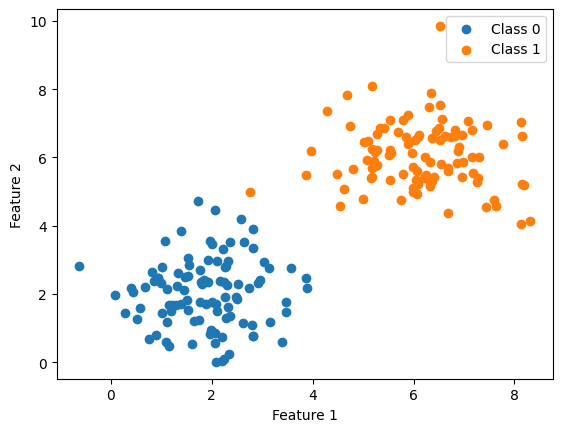

In [2]:

np.random.seed(42)

n = 100
# Class 0
X0 = np.random.randn(n, 2) + np.array([2, 2])
y0 = np.zeros(n)
# Class 1
X1 = np.random.randn(n, 2) + np.array([6, 6])
y1 = np.ones(n)
# Combine
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))
# Shuffle dataset
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]
print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 X values:\n", X[:5])
print("First 5 y values:\n", y[:5])

# Visualize
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [3]:
def step_function(x):
    return 1 if x >= 0 else 0

In [4]:
def perceptron(X, y, learning_rate=0.1, n_epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    for epoch in range(n_epochs):
        for idx, x_i in enumerate(X):
            linear_output = np.dot(x_i, weights) + bias
            y_predicted = step_function(linear_output)

            # Update weights and bias
            update = learning_rate*(y[idx]-y_predicted)
            weights += update * x_i
            bias += update

    return weights, bias

In [11]:

w, b = perceptron(X, y, learning_rate=0.1, n_epochs=1000)
m=-w[0]/w[1]
c=-b/w[1]

Y = m*X[:,0]+c
Y_i=-X[:,0]-1

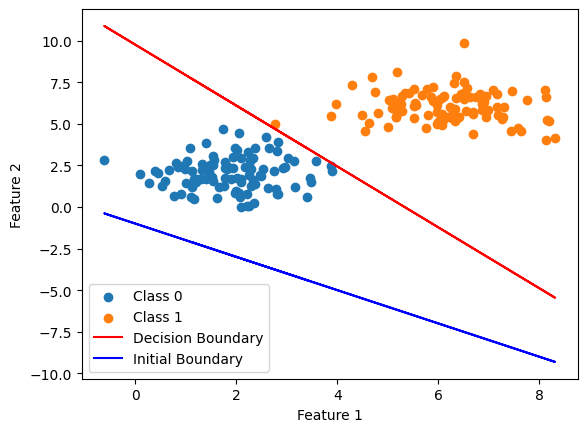

In [12]:
# Visualize decision boundary
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")
plt.plot(X[:,0], Y, color='red', label='Decision Boundary') 
plt.plot(X[:,0], Y_i, color='blue', label='Initial Boundary')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()